# Project Description

Human facial expression are a fundamental and universal form of non-verbal communication. Accurately recognizing these expressions enables better understanding of a person's emotional state, which is critical for social interactions and decision making (Suslow et al., 2023). This is especially crucial in enhancing human-computer interactions systems, where detecting a user's emotion can allow virtual assistants, robots, or applications to respond more effectively. It also has applications in healthcare, such as monitoring stress or detecting early signs of emotional disorders.

The goal of this project is to develop a deep learning model capable of classifying facial expressions into discrete emotional categories: happy, sad, angry, surprise, neutral, disgust, fear. The input to the model is a grayscale image of a human face, and the output is a predicted emotion label.

Deep learning, specifically Convolutional Neural Networks (CNNs), is  suitable approach because it excels at extracting hierachical features from images such as edges, textures, and spatial paterns. These features are crucial for distinguishing subtle differences in facial expressions. Unlike traditional machine learning methods, CNNs can learn these features automatically from raw pixel data, making them highly effective for image-based classification tasks.

# Dataset

The source dataset used in this project is FER-2013, which consists of 32,398 grayscale facial images.

Source: https://www.kaggle.com/datasets/msambare/fer2013

In [1]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots, cm
from torchvision import datasets, transforms
import os
import numpy as np
from torch.utils.data import ConcatDataset, TensorDataset
import torch
import cv2
from sklearn.model_selection import train_test_split
import shutil
import kagglehub

In [2]:
# Download latest version
dataset_path = kagglehub.dataset_download("msambare/fer2013")
print("Downloaded dataset path:", dataset_path)

# Target folder
raw_folder = "data/fer2023"
os.makedirs(raw_folder, exist_ok=True)

# Copy all contents from KaggleHub folder to your raw folder
for item in os.listdir(dataset_path):
    src = os.path.join(dataset_path, item)
    dst = os.path.join(raw_folder, item)
    if os.path.isdir(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
    else:
        shutil.copy2(src, dst)

print("Dataset copied to:", raw_folder)

Using Colab cache for faster access to the 'fer2013' dataset.
Downloaded dataset path: /kaggle/input/fer2013
Dataset copied to: data/fer2023


The original FER-2013 dataset  is already split into train and test data. However, the predefined splits may not be perfectly balanced. Hence, both sets are first combined into a single dataset, allowing for data preparation and creation of new training, validation and test splits.

In [3]:
train_dir = os.path.join(raw_folder, 'train')
test_dir = os.path.join(raw_folder, 'test')

# Define transforms
base_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor(),
])

train_data_original = datasets.ImageFolder(train_dir, transform=base_transform)
test_data_original = datasets.ImageFolder(test_dir, transform=base_transform)

print(f"Number of training images (predefined): {len(train_data_original)}")
print(f"Number of test images (predefined): {len(test_data_original)}")

dataset = ConcatDataset([train_data_original, test_data_original])
print(f"Number of images in dataset: {len(dataset)}")

Number of training images (predefined): 28709
Number of test images (predefined): 7178
Number of images in dataset: 35887


# Data Exploration

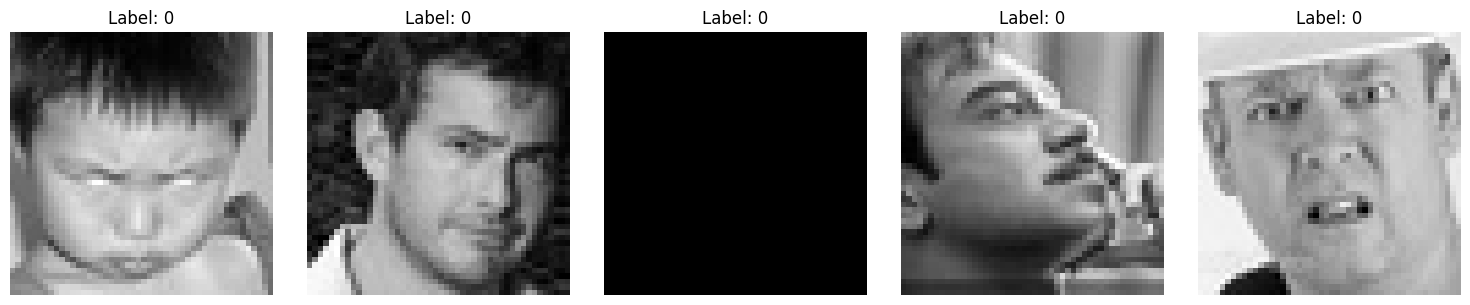

In [4]:

# Display first 5 images in a row
num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(15, 3))  # 1 row, 5 columns

for i in range(num_images):
    img_tensor, label = dataset[i]

    # Convert tensor to 2D NumPy array
    img_np = img_tensor.squeeze(0).numpy()  # [1,H,W] -> [H,W]

    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

There are some images which are completely black, meaning that all their pixel values are zero. The images will be removed as they do not provide any meaningful information and including them in the training can mislead the model.

In [5]:
clean_dataset =[]
for img, label in dataset:
  img_np = img.squeeze(0).numpy()
  if img_np.max()>0:
    clean_dataset.append((img, label))

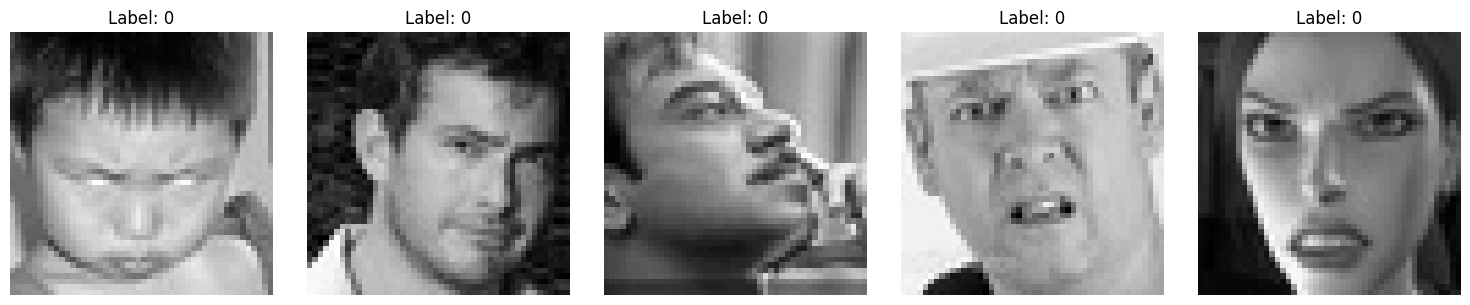

In [6]:
# Display first 5 images in a row
num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(15, 3))  # 1 row, 5 columns

for i in range(num_images):
    img_tensor, label = clean_dataset[i]

    # Convert tensor to 2D NumPy array
    img_np = img_tensor.squeeze(0).numpy()  # [1,H,W] -> [H,W]

    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

The completely black images are successfully removed.

In [7]:
# Print number of images in clean dataset
print(f"Number of images in clean dataset: {len(clean_dataset)}")

Number of images in clean dataset: 35875


In [8]:
def plot_class_distribution(dataset, title):
  """
  Plots a bar chart showing the number of samples for each class.

  Args:
    dataset: The dataset to plot.
    title: The title of the plot.
  """
  # Get class names
  class_names = train_data_original.classes

  # Get all labels as a tensor
  labels = torch.tensor([label for _, label in dataset])

  # Count samples per class
  counts = torch.zeros(len(class_names), dtype=torch.int)
  for i in range(len(class_names)):
    counts[i] = (labels==i).sum()

  # Plot
  plt.figure(figsize=(10, 6))
  bars = plt.bar(class_names, counts.numpy(), color='skyblue')
  plt.xlabel('Class')
  plt.ylabel('Number of Samples')
  plt.title(title)
  plt.xticks(rotation=45)

  for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(count.item()), ha='center', va='bottom', fontsize=10)

  plt.tight_layout()
  plt.show()

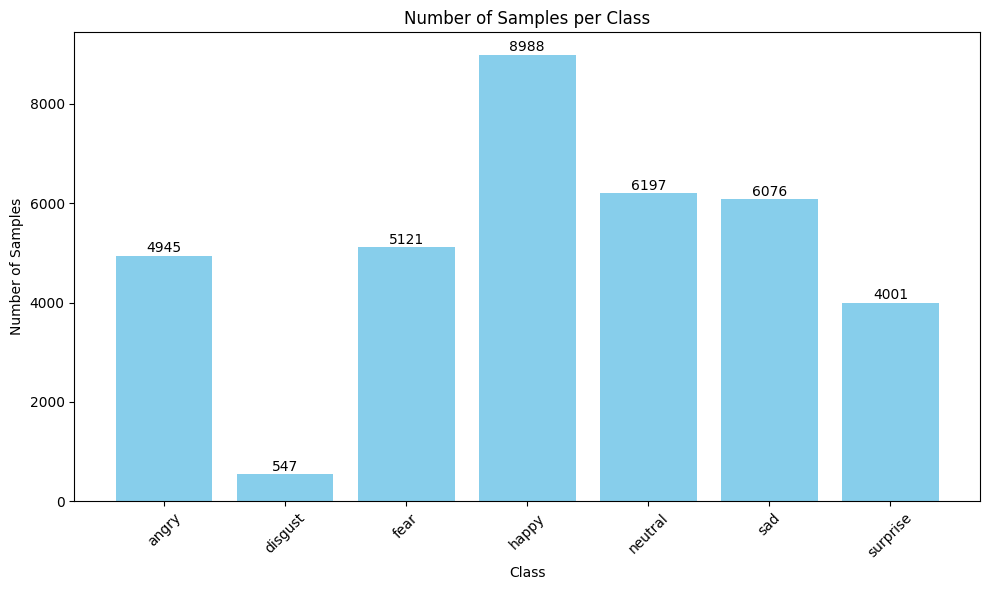

In [9]:
plot_class_distribution(clean_dataset, "Number of Samples per Class")

# Data Preprocessing

### 1. Splitting the Dataset
The dataset will be splitted into training (70%), validation(15%) and test (15%). The training set is used to teach the model, the validation set helps with hyperparameter tuning and test set evaluates the model's performance on unseen data.

`shuffle` parameter ensures samples are randomly distributed

`stratify` parameter ensures class proportions are maintained in each split.

In [10]:
# Convert dataset to (numpy_img, label)
dataset_array = [
    ((img.squeeze(0).numpy() * 255).astype(np.uint8), label)
    for img, label in clean_dataset
]

# Extract labels for stratification
labels = [label for _, label in dataset_array]

# Split into train / temp
train_set, temp_set = train_test_split(
    dataset_array,
    test_size=0.30,
    stratify=labels,
    shuffle=True
)

# Split temp → val and test
temp_labels = [label for _, label in temp_set]

val_set, test_set = train_test_split(
    temp_set,
    test_size=0.50,
    stratify=temp_labels,
    shuffle=True
)


### 2. Histogram Equalization
 Applied to each image to enhance contrast and brings out facial features such as eyebrowns and mouth curvature.

 Source: https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_histograms/py_histogram_equalization/py_histogram_equalization.html

### 3. Gamma Correction
Used to normalize lighting variations across the dataset. This ensures that faces captured under different illumination conditions are processed consistently.

Source: https://medium.com/@sinhaaa003/transforming-images-rgb-to-grayscale-and-gamma-correction-with-python-fe5a0afa12b9

### 4. Normalization
All pixel values are scaled to the range [-1,1] to stablize gradient updates during training.

In [11]:
def histogram_equalization(img):
  """
  Apply histogram equalization to a single grayscale image (NumPy array).
  Args:
    img: 2D NumPy array, dtype uint8
  Returns:
    equalized 2D NumPy array, uint8
  """
  if img.dtype != np.uint8:
      raise ValueError("Image must be uint8")
  return cv2.equalizeHist(img)

def gamma_correction(img, gamma=0.9):
  """
  Apply gamma correction to a single grayscale image (NumPy array).
  Args:
    img: 2D NumPy array, uint8
    gamma: gamma value
  Returns:
    gamma-corrected 2D NumPy array, uint8
  """
  img_float = img / 255.0
  img_gamma = np.power(img_float, gamma)
  img_out = np.clip(img_gamma * 255, 0, 255).astype(np.uint8)
  return img_out


def to_tensor_normalized(img):
  """
  Convert 2D NumPy grayscale image to PyTorch tensor [1, H, W].
  normalize: scale to [-1, 1] if True
  Args:
    img: 2D NumPy array, uint8
  Returns:
    tensor: PyTorch tensor
  """
  tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0) / 255.0
  tensor = (tensor - 0.5) / 0.5
  return tensor


def preprocess(img, gamma=0.9): # hyperparameter gamma
  """
  Full preprocessing pipeline for one grayscale image (NumPy array)
  Args:
    img: 2D NumPy array, uint8
    gamma: gamma value for gamma correction
  Returns:
    tensor: PyTorch tensor
  """
  img = histogram_equalization(img)
  img = gamma_correction(img, gamma)
  tensor = to_tensor_normalized(img)
  return tensor

In [12]:
# Preprocess TRAIN/VAL/TEST set
processed_train = [
    (preprocess(img_np), label)
    for img_np, label in train_set
]

processed_val = [
    (preprocess(img_np), label)
    for img_np, label in val_set
]

processed_test = [
    (preprocess(img_np), label)
    for img_np, label in test_set
]

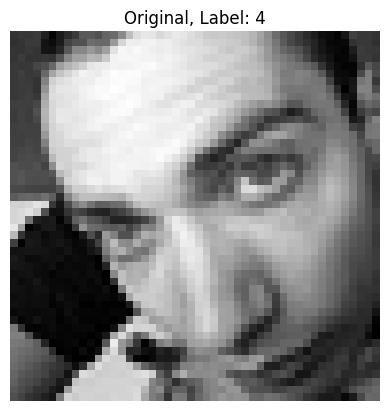

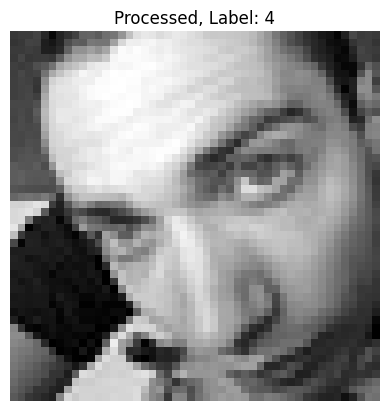

In [13]:
def show_image(img, title=None):
  """
  Display a single grayscale image.
  Args:
    img: 2D NumPy array (dtype uint8) or PyTorch tensor
  """
  if img.dtype == np.uint8:
    img = img.astype(np.float32) / 255.0
  else:
    raise ValueError("NumPy image must be uint8")

  # Display
  plt.imshow(img, cmap='gray')
  if title is not None:
      plt.title(title)
  plt.axis('off')
  plt.show()

def show_processed_image(img, title=None):
  """
  Display a single grayscale image.
  Args:
    img: 2D NumPy array (dtype uint8) or PyTorch tensor
    title: Optional title for the plot
  """
  img = img.squeeze(0)           # [H,W]
  img = (img * 0.5) + 0.5        # undo normalization [-1,1] -> [0,1]
  img = img.clamp(0, 1)          # ensure valid range
  img = img.numpy()

  plt.imshow(img, cmap='gray')
  if title is not None:
      plt.title(title)
  plt.axis('off')
  plt.show()


# Display a random image, perhaps index = 2000
# Original image
original_img, label = train_set[1]
show_image(original_img, title=f"Original, Label: {label}")

# Processed image
processed_img, label = processed_train[1]
show_processed_image(processed_img, title=f"Processed, Label: {label}")

### 5. Data Augmentation

In [14]:
# Set to True to perform augmentation, False to use original processed data
USE_AUGMENTATION = True
classes_to_augment= [0,1,2,3,4,5,6,7]

if USE_AUGMENTATION:
    # Define augmentation transforms
    augmentation_transforms = transforms.Compose([
      transforms.RandomRotation(degrees=10),           # ±10° rotation
      transforms.RandomAffine(
          degrees=0,                                   # already rotated above
          translate=(0.1, 0.1),                        # ±10% shift
          scale=(0.9, 1.1)                             # ±10% zoom
      ),
      transforms.RandomHorizontalFlip(p=0.5),          # 50% chance
    ])
    augmented_images = []
    augmented_labels = []

    for img_tensor, label in processed_train:
        if label in classes_to_augment:
            for _ in range(5): # number of augmented copies per image
                augmented_img = augmentation_transforms(img_tensor)
                augmented_images.append(augmented_img)
                augmented_labels.append(label)

    # Convert original dataset tensors + labels to lists
    original_images = [img for img, label in processed_train]
    original_labels = [label for img, label in processed_train]

    # Combine original + augmented
    all_images = original_images + augmented_images
    all_labels = original_labels + augmented_labels
else:
    # No augmentation: use processed training data as-is
    augmented_images = []
    augmented_labels = []
    all_images = [img for img, label in processed_train]
    all_labels = [label for img, label in processed_train]

# Stack into tensors
train_X_tensor = torch.stack(all_images)
train_y_tensor = torch.tensor(all_labels)

# Create Tensor Dataset (kept name for compatibility with later cells)
augmented_processed_train = TensorDataset(train_X_tensor, train_y_tensor)


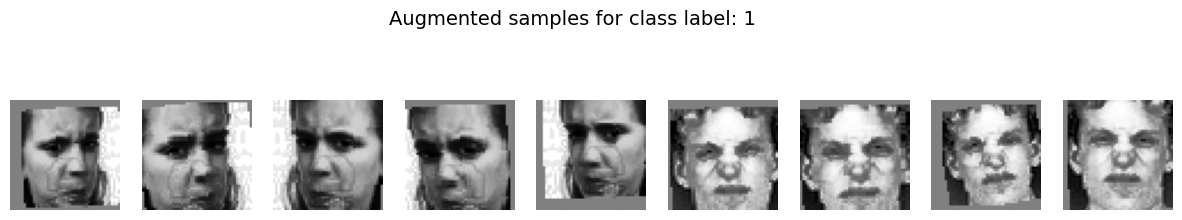

In [15]:
def show_augmented_samples(images, labels, class_label, n):
    """
    Display first n augmented images of a given class label.
    Args:
        images: List of augmented images.
        labels: List of corresponding labels.
        class_label: Label for which to display augmented images.
        n: Number of images to display.
    """
    selected = [img for img, lbl in zip(images, labels) if lbl == class_label][:n]
    plt.figure(figsize=(15, 3))
    for i, img in enumerate(selected):
        plt.subplot(1, n, i + 1)
        plt.imshow(img.squeeze(0), cmap='gray')  # img is tensor [1,H,W]
        plt.axis('off')
    plt.suptitle(f"Augmented samples for class label: {class_label}", fontsize=14)
    plt.show()


# Display 10 augmented "disgust" images
show_augmented_samples(augmented_images, augmented_labels, class_label=1, n=9)

In [16]:
# Print number of images in balanced train dataset
print(f"Number of images in balanced train dataset: {len(augmented_processed_train)}")

Number of images in balanced train dataset: 150672


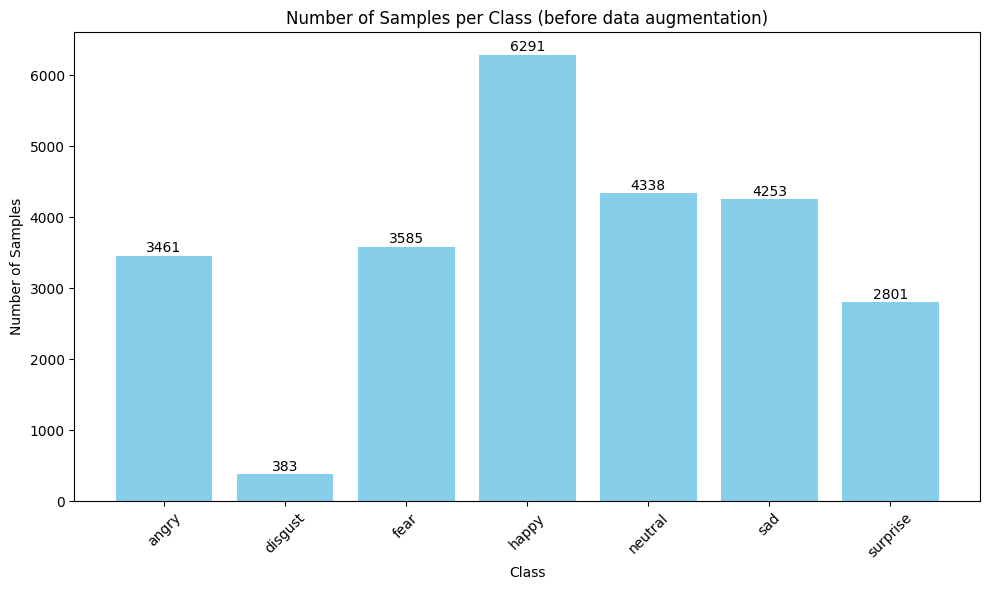

In [17]:
# Plot the distribution beforedata augmentation
plot_class_distribution(processed_train, "Number of Samples per Class (before data augmentation)")

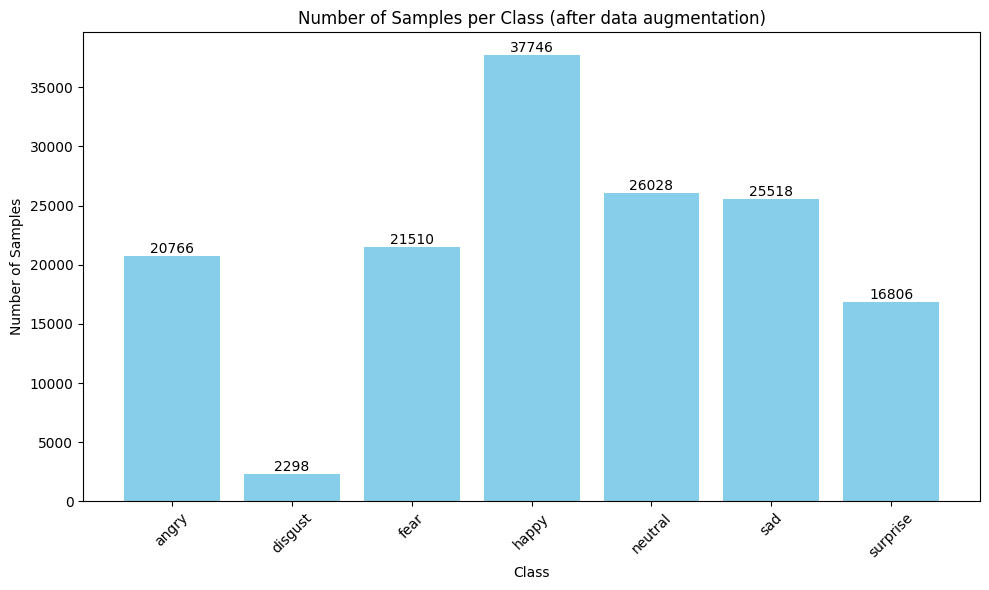

In [18]:
# Plot the distribution after data augmentation
plot_class_distribution(augmented_processed_train, "Number of Samples per Class (after data augmentation)")

# Baseline Model

The baseline model used is Support Vector Machines. SVM is able to handle mutli-class classification and does not require deep learning infrastructure. Hence, it serves as a good reference.

In order to fit an SVM using a non-linear kernel, we use `kernel="rbf"`. The `gamma` parameter defines how far the influence of a single training example reaches, with low values meaning ‘far’ and high values meaning ‘close’.

The `C` parameter trades off correct classification of training examples against maximization of the decision function’s margin. For larger values of C, a smaller margin will be accepted if the decision function is better at classifying all training points correctly. A lower C will encourage a larger margin, therefore a simpler decision function, at the cost of training accuracy. In other words C behaves as a regularization parameter in the SVM.

Before training the model, PCA will be performed to reduce the dimensionality of data, while preserving as much variance as possible.

In [19]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import random

In [20]:
val_X = [img for img, label in processed_val]
val_Y = [label for img, label in processed_val]
test_X = [img for img, label in processed_test]
test_Y = [label for img, label in processed_test]

# Convert lists into tensors
val_X_tensor   = torch.stack(val_X) # [N, 1, H, W]
test_X_tensor  = torch.stack(test_X)
val_y_tensor   = torch.tensor(val_Y)
test_y_tensor  = torch.tensor(test_Y)

# Flatten images
train_X_svm = train_X_tensor.view(train_X_tensor.size(0), -1).numpy()
val_X_svm   = val_X_tensor.view(val_X_tensor.size(0), -1).numpy()
test_X_svm  = test_X_tensor.view(test_X_tensor.size(0), -1).numpy()

train_y_svm = train_y_tensor.numpy()
val_y_svm = val_y_tensor.numpy()
test_y_svm = test_y_tensor.numpy()

In [ ]:
# Reduce dimensionality with PCA
pca = PCA(n_components=100)  # keep 100 principal components
train_X_pca = pca.fit_transform(train_X_svm)
val_X_pca = pca.transform(val_X_svm)
test_X_pca = pca.transform(test_X_svm)

# Train SVM with RBF kernel
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(train_X_pca, train_y_svm)

SVC()

In [ ]:
# Validation Accuracy
val_pred = svm_model.predict(val_X_pca)
val_acc = accuracy_score(val_y_svm, val_pred)
print(f"Validation Accuracy: {val_acc:.3f}")

# Test Accuracy
test_pred = svm_model.predict(test_X_pca)
test_acc = accuracy_score(test_y_svm, test_pred)
print(f"Test Accuracy: {test_acc:.3f}")

# Detailed report
print("Classification Report (Test set):")
print(classification_report(test_y_svm, test_pred))

Validation Accuracy: 0.484
Test Accuracy: 0.481
Classification Report (Test set):
              precision    recall  f1-score   support

           0       0.42      0.32      0.37       742
           1       0.92      0.13      0.23        82
           2       0.39      0.23      0.29       768
           3       0.57      0.76      0.65      1349
           4       0.41      0.47      0.44       930
           5       0.37      0.40      0.38       911
           6       0.65      0.57      0.61       600

    accuracy                           0.48      5382
   macro avg       0.53      0.41      0.42      5382
weighted avg       0.48      0.48      0.47      5382



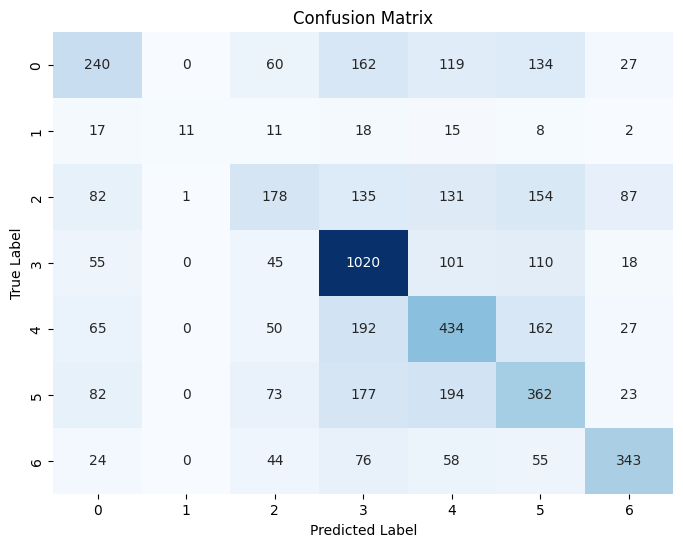

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(test_y_svm,  test_pred)

# Plot using seaborn heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Primary Model



In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt # for plotting
import torch.optim as optim #for gradient descent

import time

In [22]:
# Wrap in TensorDataset
train_dataset = TensorDataset(train_X_tensor, train_y_tensor)
val_dataset = TensorDataset(val_X_tensor, val_y_tensor)
test_dataset = TensorDataset(test_X_tensor, test_y_tensor)

### Training Utils

In [23]:
def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

In [24]:
def get_accuracy(model, batch_size=64, train=False):
  """
  Compute the classification accuracy of a PyTorch model on either the training
  or validation dataset.

  Args:
      model (torch.nn.Module): The trained model to evaluate.
      batch_size (int): Number of samples per batch during evaluation.
      train (bool): If True, evaluate on the training set; otherwise, on the validation set.

  Returns:
      float: The accuracy (0–1) of the model on the selected dataset.
  """
  if train:
        data = train_dataset
  else:
      data = val_dataset

  loader = torch.utils.data.DataLoader(data, batch_size=batch_size)
  correct = 0
  total = 0
  with torch.no_grad():
        for imgs, labels in loader:
            if use_cuda and torch.cuda.is_available():
                imgs, labels = imgs.cuda(), labels.cuda()
            out = model(imgs)
            preds = torch.argmax(out, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
  model.train()  # back to training mode
  return correct / total

In [25]:
def train(model, train_set, val_set, batch_size=64, lr=0.001, num_epochs=20, weight_decay=1e-4):
    """
    Train a neural network model with AdamW optimizer, weight decay, and a ReduceLROnPlateau scheduler.

    Args:
        model (nn.Module): PyTorch model to train
        train_set (Dataset): Training dataset
        val_set (Dataset): Validation dataset
        batch_size (int): Batch size
        lr (float): Learning rate
        num_epochs (int): Number of epochs
        weight_decay (float): Weight decay (L2) for optimizer
    """

    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader   = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_loss_list = []
    val_loss_list = []
    train_acc_list = []
    val_acc_list = []

    start_time = time.time()

    # Prepare checkpoint directories
    checkpoints_dir = "checkpoints"
    os.makedirs(checkpoints_dir, exist_ok=True)

    # Track best validation accuracy
    best_val_acc = -1.0

    for epoch in range(num_epochs):

        # -----------------------
        #        TRAINING
        # -----------------------
        model.train()
        running_train_loss = 0.0

        for imgs, labels in train_loader:
            if torch.cuda.is_available():
                imgs = imgs.cuda()
                labels = labels.cuda()

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * imgs.size(0)  # sum loss

        epoch_train_loss = running_train_loss / len(train_set)
        train_loss_list.append(epoch_train_loss)

        # -----------------------
        #     VALIDATION
        # -----------------------
        model.eval()
        running_val_loss = 0.0
        correct = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                if torch.cuda.is_available():
                    imgs = imgs.cuda()
                    labels = labels.cuda()

                out = model(imgs)
                loss = criterion(out, labels)
                running_val_loss += loss.item() * imgs.size(0)

                preds = torch.argmax(out, dim=1)
                correct += (preds == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_set)
        val_loss_list.append(epoch_val_loss)

        val_acc = correct / len(val_set)
        train_acc = get_accuracy(model, batch_size, train=True)

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        # Save per-epoch checkpoint
        model_filename = get_model_name(model.name, batch_size, lr, epoch+1) + ".pt"
        model_path = os.path.join(checkpoints_dir, model_filename)
        torch.save(model.state_dict(), model_path)


    # -----------------------
    #       PLOTTING
    # -----------------------
    plt.figure()
    plt.plot(train_loss_list, label="Train Loss")
    plt.plot(val_loss_list, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(train_acc_list, label="Train Accuracy")
    plt.plot(val_acc_list, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()
    plt.show()

    return train_loss_list, val_loss_list, train_acc_list, val_acc_list


### CNN Model

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes=7, dropout=0.3):
        super().__init__()
        self.name = "cnn"

        # ==== Block 1 ====
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        # ==== Block 2 ====
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout2d(dropout)

        # ==== Block 3 ====
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        # ==== Block 4 ====
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.drop4 = nn.Dropout2d(dropout)

        # ==== Block 5 ====
        self.conv5 = nn.Conv2d(256, 512, 3, padding=1)
        self.bn5   = nn.BatchNorm2d(512)
        self.pool5 = nn.MaxPool2d(2, 2)

        # 48 -> 24 -> 12 -> 6 -> 3 -> 1
        self.flatten_dim = 512 * 1 * 1

        self.fc1 = nn.Linear(self.flatten_dim, 256)
        self.drop_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):

        x = self.pool1(self.bn1(F.relu(self.conv1(x))))

        x = self.pool2(self.bn2(F.relu(self.conv2(x))))
        x = self.drop2(x)

        x = self.pool3(self.bn3(F.relu(self.conv3(x))))

        x = self.pool4(self.bn4(F.relu(self.conv4(x))))
        x = self.drop4(x)

        x = self.pool5(self.bn5(F.relu(self.conv5(x))))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)

        return x

### Train Data

CUDA is available!  Training on GPU ...
Epoch 1/200 | Train Loss: 1.4029 | Val Loss: 1.1572 | Train Acc: 0.5694 | Val Acc: 0.5564
Epoch 2/200 | Train Loss: 1.1813 | Val Loss: 1.0652 | Train Acc: 0.6192 | Val Acc: 0.5912
Epoch 3/200 | Train Loss: 1.0913 | Val Loss: 1.0248 | Train Acc: 0.6518 | Val Acc: 0.6038
Epoch 4/200 | Train Loss: 1.0239 | Val Loss: 1.0169 | Train Acc: 0.6836 | Val Acc: 0.6252
Epoch 5/200 | Train Loss: 0.9669 | Val Loss: 1.0000 | Train Acc: 0.7079 | Val Acc: 0.6304
Epoch 6/200 | Train Loss: 0.9198 | Val Loss: 1.0008 | Train Acc: 0.7341 | Val Acc: 0.6307
Epoch 7/200 | Train Loss: 0.8679 | Val Loss: 1.0059 | Train Acc: 0.7554 | Val Acc: 0.6337
Epoch 8/200 | Train Loss: 0.8306 | Val Loss: 1.0039 | Train Acc: 0.7783 | Val Acc: 0.6417
Epoch 9/200 | Train Loss: 0.7863 | Val Loss: 1.0297 | Train Acc: 0.7985 | Val Acc: 0.6441
Epoch 10/200 | Train Loss: 0.7482 | Val Loss: 1.0523 | Train Acc: 0.8204 | Val Acc: 0.6534
Epoch 11/200 | Train Loss: 0.7114 | Val Loss: 1.0529 | Trai

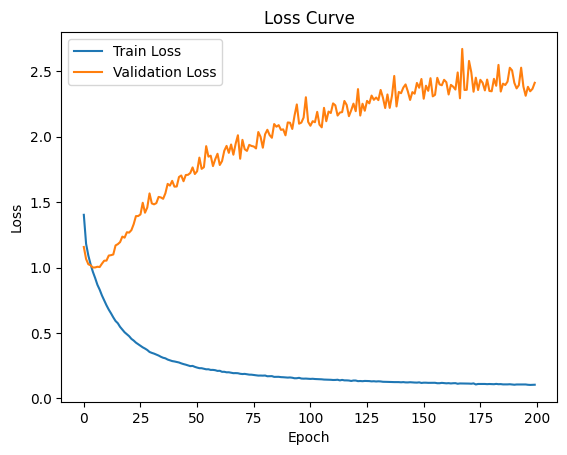

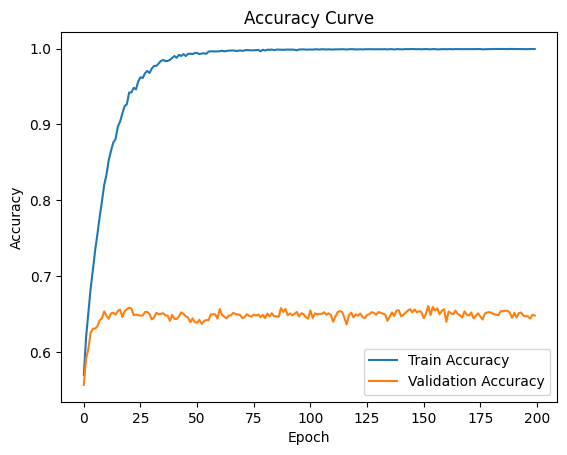

([1.402905821787573,
  1.1812659909014516,
  1.0912824610786807,
  1.0238977419136308,
  0.9668878599680114,
  0.9198018193333547,
  0.867915963106276,
  0.8306057183519979,
  0.7863026195503134,
  0.7481718565724743,
  0.7113854270762694,
  0.6784212319153667,
  0.6498331832027465,
  0.6191172678024763,
  0.5914821558074864,
  0.5742993020854381,
  0.5464733065431052,
  0.5257271725660273,
  0.5051314344249284,
  0.49041558379477296,
  0.47524411006820444,
  0.45481866178168756,
  0.4418885157998104,
  0.42585599324506246,
  0.41424440509690413,
  0.4018381851056433,
  0.39000096672360046,
  0.38061151307147817,
  0.3697450254972895,
  0.35476414088760705,
  0.3477649775719306,
  0.3419782048332801,
  0.3345660079732257,
  0.3273882734078668,
  0.3179003913673522,
  0.3104375654741927,
  0.30604373955650355,
  0.29662772149774846,
  0.290883129271331,
  0.2850204041193875,
  0.2820561903792828,
  0.27794747923811275,
  0.27423805042901933,
  0.2674638083149442,
  0.26195916146304216,


In [27]:
use_cuda = True

model = CNN()
if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')
train(model, train_dataset, val_dataset, batch_size=32, lr=0.001, weight_decay=1e-4, num_epochs=200)

### Test model

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score
import numpy as np

def get_accuracy_test(model, batch_size, class_names=None, plot=True):
    """
    Compute overall accuracy, per-class accuracy, precision, and recall
    for a PyTorch model on the test dataset.

    Args:
        model (torch.nn.Module): The trained model to evaluate.
        batch_size (int): Number of samples per batch during evaluation
    Returns:
        dict: A dictionary containing the overall accuracy, per-class accuracy,
              precision, and recall for each class.
    """

    model.eval()
    data = test_dataset
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in torch.utils.data.DataLoader(data, batch_size=batch_size):

            if use_cuda and torch.cuda.is_available():
                imgs = imgs.cuda()
                labels = labels.cuda()

            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # === Overall Accuracy ===
    accuracy = correct / total

    # === Per-Class Accuracy ===
    num_classes = len(class_names) if class_names else max(all_labels) + 1
    per_class_accuracy = []

    for c in range(num_classes):
        idx = (all_labels == c)
        if idx.sum() == 0:
            acc = np.nan
        else:
            acc = (all_preds[idx] == c).mean()
        per_class_accuracy.append(acc)

    # === Per-Class Precision & Recall ===
    precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
    recall = recall_score(all_labels, all_preds, average=None, zero_division=0)

    # === Confusion Matrix ===
    if plot:
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

        fig, ax = plt.subplots(figsize=(8, 6))
        disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
        plt.title(f'Confusion Matrix (Accuracy: {accuracy*100:.2f}%)')
        plt.xticks(rotation=45)
        plt.show()

    # === Print Metrics ===
    print("\n=== Classification Metrics ===")
    print(f"Overall Accuracy: {accuracy*100:.2f}%\n")

    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]

    print("Per-Class Metrics:")
    for i, name in enumerate(class_names):
        print(f"  {name:10s} | Acc: {per_class_accuracy[i]*100:6.2f}% "
              f"| Prec: {precision[i]*100:6.2f}% | Rec: {recall[i]*100:6.2f}%")

    return {
        "overall_accuracy": accuracy,
        "per_class_accuracy": per_class_accuracy,
        "precision": precision,
        "recall": recall
    }


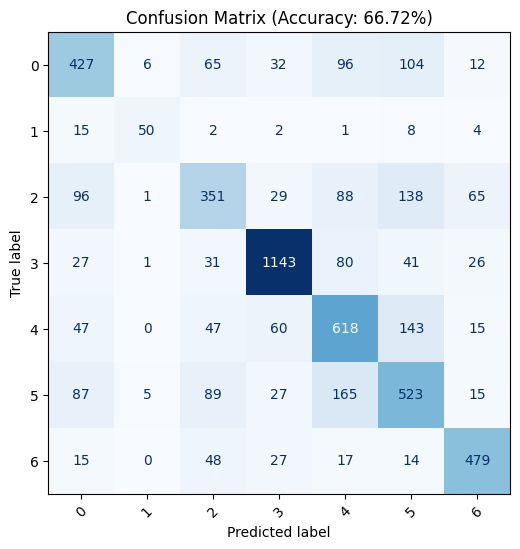


=== Classification Metrics ===
Overall Accuracy: 66.72%

Per-Class Metrics:
  Class 0    | Acc:  57.55% | Prec:  59.80% | Rec:  57.55%
  Class 1    | Acc:  60.98% | Prec:  79.37% | Rec:  60.98%
  Class 2    | Acc:  45.70% | Prec:  55.45% | Rec:  45.70%
  Class 3    | Acc:  84.73% | Prec:  86.59% | Rec:  84.73%
  Class 4    | Acc:  66.45% | Prec:  58.03% | Rec:  66.45%
  Class 5    | Acc:  57.41% | Prec:  53.86% | Rec:  57.41%
  Class 6    | Acc:  79.83% | Prec:  77.76% | Rec:  79.83%
Test accuracy:  {'overall_accuracy': 0.6672240802675585, 'per_class_accuracy': [np.float64(0.5754716981132075), np.float64(0.6097560975609756), np.float64(0.45703125), np.float64(0.8472942920681986), np.float64(0.6645161290322581), np.float64(0.5740944017563118), np.float64(0.7983333333333333)], 'precision': array([0.59803922, 0.79365079, 0.55450237, 0.86590909, 0.58028169,
       0.53861998, 0.7775974 ]), 'recall': array([0.5754717 , 0.6097561 , 0.45703125, 0.84729429, 0.66451613,
       0.5740944 , 0.79

In [31]:
best_model = CNN()
model_path = "checkpoints/model_cnn_bs32_lr0.001_epoch21.pt" # select best checkpoint
best_model.load_state_dict(torch.load(model_path, map_location='cuda' if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"))
if use_cuda and torch.cuda.is_available():
    best_model.cuda()

test_acc = get_accuracy_test(best_model, batch_size=64)
print("Test accuracy: ", test_acc)

# Final Test

For final testing, we evaluate the model on the CK+ dataset, which contains 920 grayscale facial images across eight emotion classes (angry, contempt, disgust, fear, happy, neutral, sad, surprise) (Sena, 2020). To ensure comparability with our training data, CK+ is preprocessed using the same pipeline (grayscale conversion, resizing, and normalization). We also verify that the emotion labels align across datasets. Fairness is assessed by reporting per-class accuracy and confusion matrices, allowing us to inspect whether the model performs consistently across all emotion categories.

In [32]:
import pandas as pd

In [33]:
# Download CK+ dataset using kagglehub
dataset_path = kagglehub.dataset_download("davilsena/ckdataset")
print("Downloaded dataset path:", dataset_path)

# Target folder
raw_folder = "data/ck+"
os.makedirs(raw_folder, exist_ok=True)

# Copy all contents from KaggleHub folder to your raw folder
for item in os.listdir(dataset_path):
    src = os.path.join(dataset_path, item)
    dst = os.path.join(raw_folder, item)
    if os.path.isdir(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
    else:
        shutil.copy2(src, dst)

print("Dataset copied to:", raw_folder)

100%|██████████| 2.48M/2.48M [00:00<00:00, 141MB/s]

Extracting files...
Downloaded dataset path: /root/.cache/kagglehub/datasets/davilsena/ckdataset/versions/2
Dataset copied to: data/ck+


In [34]:
# Your model classes:
# 0 angry
# 1 disgust
# 2 fear
# 3 happy
# 4 neutral
# 5 sad
# 6 surprise

# CK+ classes (FER-style):
# 0 anggry
# 1 disgust
# 2 Fear
# 3 Happiness
# 4 Sadness
# 5 Surprise
# 6 Neutral
# 7 Contempt

ck_to_model = {
    0: 0,   # Anger     → angry
    1: 1,   # Disgust   → disgust
    2: 2,   # Fear      → fear
    3: 3,   # Happiness → happy
    4: 5,   # Sadness   → sad
    5: 6,   # Surprise  → surprise
    6: 4,   # Neutral   → neutral
    7: None # Contempt  → dropped
}

class_names = ["angry","disgust","fear","happy","neutral","sad","surprise"]

In [35]:
# CSV path in your copied folder
csv_path = os.path.join("data", "ck+", "ckextended.csv")

# Load the CSV
df = pd.read_csv(csv_path)

# drop contempt
df = df[df["emotion"] != 1].reset_index(drop=True)

test_imgs = []
test_labels = []

for idx, row in df.iterrows():

    # map CK+ → model labels
    mapped = ck_to_model[row["emotion"]]
    if mapped is None:
        continue

    # convert to tensor (1,48,48)
    pixels = np.array(row["pixels"].split(), dtype=np.uint8).reshape(48,48)

    img_tensor = preprocess(pixels, gamma=0.9)

    test_imgs.append(img_tensor)
    test_labels.append(mapped)

test_imgs = torch.stack(test_imgs)
test_labels = torch.tensor(test_labels)

new_test_dataset = TensorDataset(test_imgs, test_labels)

print("Loaded CK+ test samples:", len(new_test_dataset))


Loaded CK+ test samples: 843


In [36]:
def get_accuracy_test(model, batch_size, class_names=None, plot=True):
    """
    Compute overall accuracy, per-class accuracy, precision, and recall
    for a PyTorch model on the test dataset.

    Args:
        model (torch.nn.Module): The trained model to evaluate.
        batch_size (int): Number of samples per batch during evaluation
    Returns:
        dict: A dictionary containing the overall accuracy, per-class accuracy,
              precision, and recall for each class.
    """

    model.eval()
    data = new_test_dataset
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in torch.utils.data.DataLoader(data, batch_size=batch_size):

            if use_cuda and torch.cuda.is_available():
                imgs = imgs.cuda()
                labels = labels.cuda()

            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # === Overall Accuracy ===
    accuracy = correct / total

    # === Per-Class Accuracy ===
    num_classes = len(class_names) if class_names else max(all_labels) + 1
    per_class_accuracy = []

    for c in range(num_classes):
        idx = (all_labels == c)
        if idx.sum() == 0:
            acc = np.nan
        else:
            acc = (all_preds[idx] == c).mean()
        per_class_accuracy.append(acc)

    # === Per-Class Precision & Recall ===
    precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
    recall = recall_score(all_labels, all_preds, average=None, zero_division=0)

    # === Confusion Matrix ===
    if plot:
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

        fig, ax = plt.subplots(figsize=(8, 6))
        disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
        plt.title(f'Confusion Matrix (Accuracy: {accuracy*100:.2f}%)')
        plt.xticks(rotation=45)
        plt.show()

    # === Print Metrics ===
    print("\n=== Classification Metrics ===")
    print(f"Overall Accuracy: {accuracy*100:.2f}%\n")

    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]

    print("Per-Class Metrics:")
    for i, name in enumerate(class_names):
        print(f"  {name:10s} | Acc: {per_class_accuracy[i]*100:6.2f}% "
              f"| Prec: {precision[i]*100:6.2f}% | Rec: {recall[i]*100:6.2f}%")

    return {
        "overall_accuracy": accuracy,
        "per_class_accuracy": per_class_accuracy,
        "precision": precision,
        "recall": recall
    }


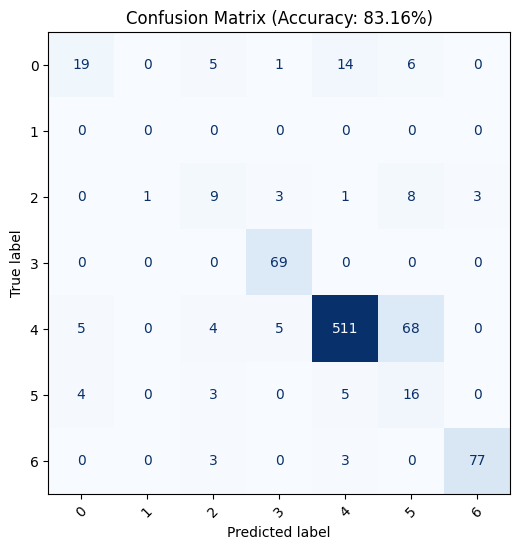


=== Classification Metrics ===
Overall Accuracy: 83.16%

Per-Class Metrics:
  Class 0    | Acc:  42.22% | Prec:  67.86% | Rec:  42.22%
  Class 1    | Acc:    nan% | Prec:   0.00% | Rec:   0.00%
  Class 2    | Acc:  36.00% | Prec:  37.50% | Rec:  36.00%
  Class 3    | Acc: 100.00% | Prec:  88.46% | Rec: 100.00%
  Class 4    | Acc:  86.17% | Prec:  95.69% | Rec:  86.17%
  Class 5    | Acc:  57.14% | Prec:  16.33% | Rec:  57.14%
  Class 6    | Acc:  92.77% | Prec:  96.25% | Rec:  92.77%
Test accuracy:  {'overall_accuracy': 0.8315539739027283, 'per_class_accuracy': [np.float64(0.4222222222222222), nan, np.float64(0.36), np.float64(1.0), np.float64(0.8617200674536256), np.float64(0.5714285714285714), np.float64(0.927710843373494)], 'precision': array([0.67857143, 0.        , 0.375     , 0.88461538, 0.95692884,
       0.16326531, 0.9625    ]), 'recall': array([0.42222222, 0.        , 0.36      , 1.        , 0.86172007,
       0.57142857, 0.92771084])}


In [43]:
best_model = CNN()
model_path = "checkpoints/model_cnn_bs32_lr0.001_epoch21.pt" # select best checkpoint
best_model.load_state_dict(torch.load(model_path, map_location='cuda' if use_cuda else 'cpu'))
if use_cuda and torch.cuda.is_available():
    best_model.cuda()

test_acc = get_accuracy_test(best_model, batch_size=64)
print("Test accuracy: ", test_acc)